In [107]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from scipy.stats import ttest_ind

pd.set_option('display.max_rows', 50) # показывать больше строк
pd.set_option('display.max_columns', 50) # показывать больше колонок


In [108]:
students = pd.read_csv('stud_math.csv')

In [109]:
display(students.head(10))
students.info()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,"studytime, granular",higher,internet,romantic,famrel,freetime,goout,health,absences,score
0,GP,F,18,U,NaN,A,4.0,4.0,at_home,teacher,course,mother,2.0,2.0,0.0,yes,no,no,no,yes,-6.0,yes,NaN,no,4.0,3.0,4.0,3.0,6.0,30.0
1,GP,F,17,U,GT3,NaN,1.0,1.0,at_home,other,course,father,1.0,2.0,0.0,no,yes,no,no,no,-6.0,yes,yes,no,5.0,3.0,3.0,3.0,4.0,30.0
2,GP,F,15,U,LE3,T,1.0,1.0,at_home,other,other,mother,1.0,2.0,3.0,yes,no,NaN,no,yes,-6.0,yes,yes,NaN,4.0,3.0,2.0,3.0,10.0,50.0
3,GP,F,15,U,GT3,T,4.0,2.0,health,NaN,home,mother,1.0,3.0,0.0,no,yes,yes,yes,yes,-9.0,yes,yes,yes,3.0,2.0,2.0,5.0,2.0,75.0
4,GP,F,16,U,GT3,T,3.0,3.0,other,other,home,father,1.0,2.0,0.0,no,yes,yes,no,yes,-6.0,yes,no,no,4.0,3.0,2.0,5.0,4.0,50.0
5,GP,M,16,U,LE3,T,4.0,3.0,services,other,reputation,mother,1.0,2.0,0.0,no,yes,yes,yes,yes,-6.0,yes,yes,no,5.0,4.0,2.0,5.0,10.0,75.0
6,GP,M,16,NaN,LE3,T,2.0,2.0,other,other,home,mother,1.0,2.0,0.0,no,no,no,no,yes,-6.0,yes,yes,no,4.0,4.0,4.0,3.0,0.0,55.0
7,GP,F,17,U,GT3,A,4.0,4.0,other,teacher,home,mother,2.0,2.0,0.0,yes,yes,no,no,yes,-6.0,yes,no,no,4.0,1.0,4.0,1.0,6.0,30.0
8,GP,M,15,U,LE3,A,3.0,2.0,services,other,home,mother,1.0,2.0,0.0,no,yes,yes,no,yes,-6.0,yes,yes,no,NaN,2.0,2.0,1.0,0.0,95.0
9,GP,M,15,U,NaN,NaN,3.0,4.0,other,other,home,mother,1.0,2.0,0.0,no,yes,yes,yes,yes,-6.0,yes,yes,no,5.0,5.0,1.0,5.0,0.0,75.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 30 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   school               395 non-null    object 
 1   sex                  395 non-null    object 
 2   age                  395 non-null    int64  
 3   address              378 non-null    object 
 4   famsize              368 non-null    object 
 5   Pstatus              350 non-null    object 
 6   Medu                 392 non-null    float64
 7   Fedu                 371 non-null    float64
 8   Mjob                 376 non-null    object 
 9   Fjob                 359 non-null    object 
 10  reason               378 non-null    object 
 11  guardian             364 non-null    object 
 12  traveltime           367 non-null    float64
 13  studytime            388 non-null    float64
 14  failures             373 non-null    float64
 15  schoolsup            386 non-null    obj

# Первичный анализ данных

# school

In [9]:
students.loc[:, ['school']].info()
pd.DataFrame(students.school.value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   school  395 non-null    object
dtypes: object(1)
memory usage: 3.2+ KB


,school
GP,349
MS,46


В данном столбце отсутствуют пустые ячейки.

# sex

In [10]:
students.loc[:, ['sex']].info()
pd.DataFrame(students.sex.value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   sex     395 non-null    object
dtypes: object(1)
memory usage: 3.2+ KB


,sex
F,208
M,187


Здесь также нет пустых ячеек.

# age

In [11]:
students.loc[:, ['age']].info()
pd.DataFrame(students.age.value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   age     395 non-null    int64
dtypes: int64(1)
memory usage: 3.2 KB


,age
16,104
17,98
18,82
15,82
19,24
20,3
22,1
21,1


Нет пустых ячеек. Но тут у нас числовой тип данных, поэтому целесообразно построить гистограмму распределения.

count    395.000000
mean      16.696203
std        1.276043
min       15.000000
25%       16.000000
50%       17.000000
75%       18.000000
max       22.000000
Name: age, dtype: float64

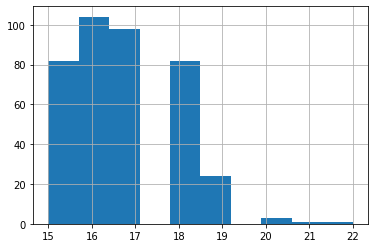

In [12]:
students.age.hist(bins = 10)
students.age.describe()

Визуально заметны выбросы в интервале 20 - 22 лет, но согласно здравому смыслу такие значения возможны, поэтому их следует оставить.

# address

In [13]:
students.loc[:, ['address']].info()
pd.DataFrame(students.address.value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   address  378 non-null    object
dtypes: object(1)
memory usage: 3.2+ KB


,address
U,295
R,83


Здесь мы видим, что имеют место незаполненные ячейки. В данном случае целесообразно заменить их на значения моды.

In [14]:
students['address'] = students['address'].apply(lambda x: 'U' if pd.isnull(x) else x)

# famsize

In [15]:
students.loc[:, ['famsize']].info()
pd.DataFrame(students.famsize.value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   famsize  368 non-null    object
dtypes: object(1)
memory usage: 3.2+ KB


,famsize
GT3,261
LE3,107


И эта колонка имеет пустые ячейки. Их также можно заменить на значения моды.

In [16]:
students['famsize'] = students['famsize'].apply(lambda x: 'GT3' if pd.isnull(x) else x)

# Pstatus

In [17]:
students.loc[:, ['Pstatus']].info()
pd.DataFrame(students.Pstatus.value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Pstatus  350 non-null    object
dtypes: object(1)
memory usage: 3.2+ KB


,Pstatus
T,314
A,36


Прописываем в пропущенных ячейках значение моды.

In [18]:
students['Pstatus'] = students['Pstatus'].apply(lambda x: 'T' if pd.isnull(x) else x)

# Medu

In [19]:
students.loc[:, ['Medu']].info()
pd.DataFrame(students.Medu.value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Medu    392 non-null    float64
dtypes: float64(1)
memory usage: 3.2 KB


,Medu
4.0,131
2.0,102
3.0,97
1.0,59
0.0,3


Здесь есть пустые ячейки. Их следует заполнить значением моды.

In [20]:
students['Medu'] = students['Medu'].apply(lambda x: float(4) if pd.isnull(x) else x)

Построим гистограмму распределения.

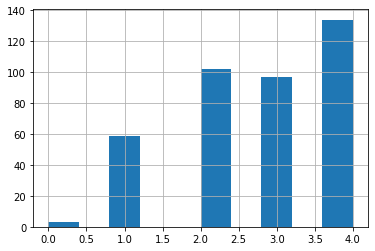

In [21]:
students.Medu.hist(bins = 10)

В целом наблюдается картина нормального распределения. Видны выбосы, но и они не противоречат здравому смыслу. Оставляем их.

# Fedu

In [22]:
students.loc[:, ['Fedu']].info()
pd.DataFrame(students.Fedu.value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Fedu    371 non-null    float64
dtypes: float64(1)
memory usage: 3.2 KB


,Fedu
2.0,106
3.0,96
4.0,88
1.0,78
0.0,2
40.0,1


Заполним пустые ячейки значением моды.

In [23]:
students['Fedu'] = students['Fedu'].apply(lambda x: float(2) if pd.isnull(x) else x)

Построим гистограмму распределения.

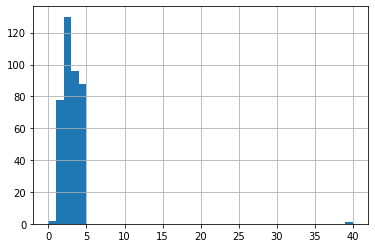

In [24]:
students.Fedu.hist(bins = 40)

В данных есть выбросы. Значение равное 40 явно противоречит здравому смыслу и очевидно, что здесь была допущена ошибка при вводе. Скорее всего здесь имелось ввиду значение 4. Значения равные 0 хоть и являются выбросами, но не противоречат здравому смыслу, поэтому их можно оставить. Перезапишем отфильтрованные данные.

In [25]:
students['Fedu'] = students['Fedu'].apply(lambda x: float(4) if x == 40 else x)

# Mjob

In [26]:
students.loc[:, ['Mjob']].info()
pd.DataFrame(students.Mjob.value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Mjob    376 non-null    object
dtypes: object(1)
memory usage: 3.2+ KB


,Mjob
other,133
services,98
at_home,58
teacher,55
health,32


Есть пустые ячейки. Прописываем в них значения моды.

In [27]:
students['Mjob'] = students['Mjob'].apply(lambda x: 'other' if pd.isnull(x) else x)

# Fjob

In [28]:
students.loc[:, ['Fjob']].info()
pd.DataFrame(students.Fjob.value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Fjob    359 non-null    object
dtypes: object(1)
memory usage: 3.2+ KB


,Fjob
other,197
services,102
teacher,29
at_home,16
health,15


Есть пустые ячейки. Заполняем их значением моды.

In [29]:
students['Fjob'] = students['Fjob'].apply(lambda x: 'other' if pd.isnull(x) else x)

# reason

In [30]:
students.loc[:, ['reason']].info()
pd.DataFrame(students.reason.value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   reason  378 non-null    object
dtypes: object(1)
memory usage: 3.2+ KB


,reason
course,137
home,104
reputation,103
other,34


Пустые ячейки заполняем значением моды.

In [31]:
students['reason'] = students['reason'].apply(lambda x: 'course' if pd.isnull(x) else x)

# guardian

In [32]:
students.loc[:, ['guardian']].info()
pd.DataFrame(students.guardian.value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 1 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   guardian  364 non-null    object
dtypes: object(1)
memory usage: 3.2+ KB


,guardian
mother,250
father,86
other,28


Заполним пустые ячейки значением моды.

In [33]:
students['guardian'] = students['guardian'].apply(lambda x: 'mother' if pd.isnull(x) else x)

# traveltime

In [34]:
students.loc[:, ['traveltime']].info()
pd.DataFrame(students.traveltime.value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   traveltime  367 non-null    float64
dtypes: float64(1)
memory usage: 3.2 KB


,traveltime
1.0,242
2.0,96
3.0,22
4.0,7


Заполним пустые ячейки значением моды.

In [35]:
students['traveltime'] = students['traveltime'].apply(lambda x: float(1) if pd.isnull(x) else x)

Построим гистограмму распределения.

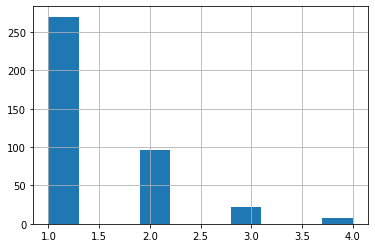

In [36]:
students.traveltime.hist(bins = 10)

# studytime

In [37]:
students.loc[:, ['studytime']].info()
pd.DataFrame(students.studytime.value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 1 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   studytime  388 non-null    float64
dtypes: float64(1)
memory usage: 3.2 KB


,studytime
2.0,194
1.0,103
3.0,64
4.0,27


Заполним пустые ячейки значением моды.

In [38]:
students['studytime'] = students['studytime'].apply(lambda x: float(2) if pd.isnull(x) else x)

Построим гистограмму распределения.

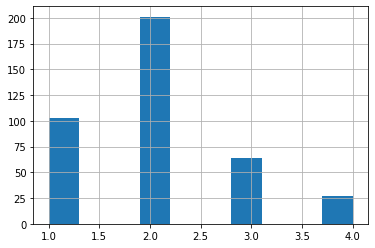

In [39]:
students.studytime.hist(bins = 10)

# failures

In [40]:
students.loc[:, ['failures']].info()
pd.DataFrame(students.failures.value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 1 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   failures  373 non-null    float64
dtypes: float64(1)
memory usage: 3.2 KB


,failures
0.0,293
1.0,49
2.0,16
3.0,15


Заполним пустые ячейки значением моды.

In [41]:
students['failures'] = students['failures'].apply(lambda x: float(0) if pd.isnull(x) else x)

Построим гистограмму распределения.

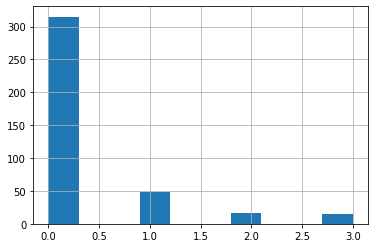

In [42]:
students.failures.hist(bins = 10)

# schoolsup

In [43]:
students.loc[:, ['schoolsup']].info()
pd.DataFrame(students.schoolsup.value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 1 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   schoolsup  386 non-null    object
dtypes: object(1)
memory usage: 3.2+ KB


,schoolsup
no,335
yes,51


Заполним пустые ячейки значением моды.

In [44]:
students['schoolsup'] = students['schoolsup'].apply(lambda x: 'no' if pd.isnull(x) else x)

# famsup

In [45]:
students.loc[:, ['famsup']].info()
pd.DataFrame(students.famsup.value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   famsup  356 non-null    object
dtypes: object(1)
memory usage: 3.2+ KB


,famsup
yes,219
no,137


Заполним пустые ячейки значением моды.

In [46]:
students['famsup'] = students['famsup'].apply(lambda x: 'yes' if pd.isnull(x) else x)

# paid

In [47]:
students.loc[:, ['paid']].info()
pd.DataFrame(students.paid.value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   paid    355 non-null    object
dtypes: object(1)
memory usage: 3.2+ KB


,paid
no,200
yes,155


Заполним пустые ячейки значением моды.

In [48]:
students['paid'] = students['paid'].apply(lambda x: 'no' if pd.isnull(x) else x)

# activities

In [49]:
students.loc[:, ['activities']].info()
pd.DataFrame(students.activities.value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   activities  381 non-null    object
dtypes: object(1)
memory usage: 3.2+ KB


,activities
yes,195
no,186


Заполним пустые ячейки значением моды.

In [50]:
students['activities'] = students['activities'].apply(lambda x: 'yes' if pd.isnull(x) else x)

# nursery

In [51]:
students.loc[:, ['nursery']].info()
pd.DataFrame(students.nursery.value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   nursery  379 non-null    object
dtypes: object(1)
memory usage: 3.2+ KB


,nursery
yes,300
no,79


Заполним пустые ячейки значением моды.

In [52]:
students['nursery'] = students['nursery'].apply(lambda x: 'yes' if pd.isnull(x) else x)

# studytime, granular

In [53]:
students.loc[:, ['studytime, granular']].info()
pd.DataFrame(students['studytime, granular'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 1 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   studytime, granular  388 non-null    float64
dtypes: float64(1)
memory usage: 3.2 KB


,"studytime, granular"
-6.0,194
-3.0,103
-9.0,64
-12.0,27


Зполним пустые ячейки значением моды.

In [54]:
students['studytime, granular'] = students['studytime, granular'].apply(lambda x: float(-6) if pd.isnull(x) else x)

# higher

In [55]:
students.loc[:, ['higher']].info()
pd.DataFrame(students.higher.value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   higher  375 non-null    object
dtypes: object(1)
memory usage: 3.2+ KB


,higher
yes,356
no,19


Заполним пустые ячейки значением моды.

In [56]:
students['higher'] = students['higher'].apply(lambda x: 'yes' if pd.isnull(x) else x)

# internet

In [57]:
students.loc[:, ['internet']].info()
pd.DataFrame(students.internet.value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 1 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   internet  361 non-null    object
dtypes: object(1)
memory usage: 3.2+ KB


,internet
yes,305
no,56


Заполним пустоты значением моды.

In [58]:
students['internet'] = students['internet'].apply(lambda x: 'yes' if pd.isnull(x) else x)

# romantic

In [59]:
students.loc[:, ['romantic']].info()
pd.DataFrame(students.romantic.value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 1 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   romantic  364 non-null    object
dtypes: object(1)
memory usage: 3.2+ KB


,romantic
no,240
yes,124


Заполняем пустоты значением моды.

In [60]:
students['romantic'] = students['romantic'].apply(lambda x: 'no' if pd.isnull(x) else x)

# famrel

In [61]:
students.loc[:, ['famrel']].info()
pd.DataFrame(students.famrel.value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   famrel  368 non-null    float64
dtypes: float64(1)
memory usage: 3.2 KB


,famrel
4.0,182
5.0,99
3.0,62
2.0,17
1.0,7
-1.0,1


Пустые ячейки заменим на значение моды.

In [62]:
students['famrel'] = students['famrel'].apply(lambda x: float(4) if pd.isnull(x) else x)

Построим гистограмму распределения.

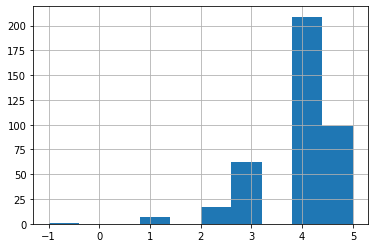

In [63]:
students.famrel.hist(bins = 10)

На графике можно заметить один нелогичный выброс равный -1. Этот выброс также заменим на значение моды.

In [64]:
students['famrel'] = students['famrel'].apply(lambda x: float(4) if x == -1 else x)

# freetime

In [65]:
students.loc[:, ['freetime']].info()
pd.DataFrame(students.freetime.value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 1 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   freetime  384 non-null    float64
dtypes: float64(1)
memory usage: 3.2 KB


,freetime
3.0,153
4.0,112
2.0,63
5.0,38
1.0,18


Заполним пустые ячейки значением моды.

In [66]:
students['freetime'] = students['freetime'].apply(lambda x: float(3) if pd.isnull(x) else x)

Построим гистограмму распределения.

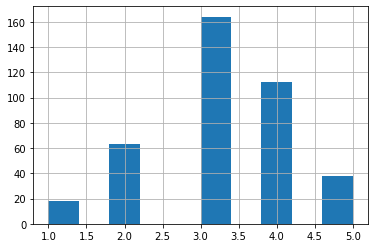

In [67]:
students.freetime.hist(bins = 10)

Распределение нормальное.

# goout

In [68]:
students.loc[:, ['goout']].info()
pd.DataFrame(students.goout.value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   goout   387 non-null    float64
dtypes: float64(1)
memory usage: 3.2 KB


,goout
3.0,127
2.0,101
4.0,84
5.0,52
1.0,23


Заполним пустые ячейки значением моды.

In [69]:
students['goout'] = students['goout'].apply(lambda x: float(3) if pd.isnull(x) else x)

Строим гистограмму распределения.

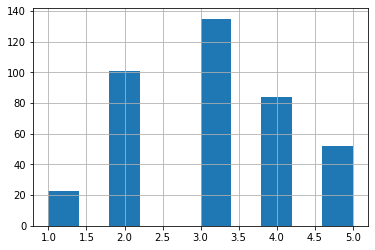

In [70]:
students.goout.hist(bins = 10)

Распределение нормальное.

# health

In [71]:
students.loc[:, ['health']].info()
pd.DataFrame(students.health.value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   health  380 non-null    float64
dtypes: float64(1)
memory usage: 3.2 KB


,health
5.0,138
3.0,89
4.0,63
1.0,47
2.0,43


Заполним пустые ячейки значением моды.

In [72]:
students['health'] = students['health'].apply(lambda x: float(5) if pd.isnull(x) else x)

Строим гистограмму распределения.

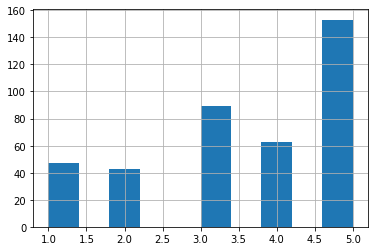

In [73]:
students.health.hist(bins = 10)

Распределение нормальное.

# absences

In [74]:
students.loc[:, ['absences']].info()
pd.DataFrame(students.absences.value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 1 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   absences  383 non-null    float64
dtypes: float64(1)
memory usage: 3.2 KB


,absences
0.0,111
2.0,60
4.0,53
6.0,31
8.0,21
10.0,17
12.0,12
14.0,12
3.0,8
16.0,7


Заполним пустые ячейки значением моды.

In [75]:
students['absences'] = students['absences'].apply(lambda x: float(0) if pd.isnull(x) else x)

Построим гистограмму распределения.

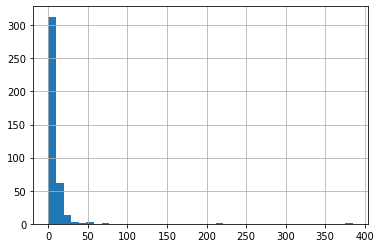

In [76]:
students.absences.hist(bins = 40)

Здесь очевидно наличие выбросов с экстремальными значениями. Отфильтруем данные выходящие за границы выбросов.

25-й перцентиль: 0.0, 75-й перцентиль: 8.0, IQR: 8.0,  Границы выбросов: [-12.0, 20.0].


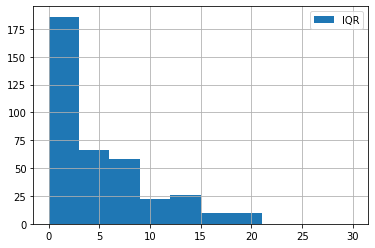

In [77]:
median = students.absences.median()
IQR = students.absences.quantile(0.75) - students.absences.quantile(0.25)
perc25 = students.absences.quantile(0.25)
perc75 = students.absences.quantile(0.75)
print('25-й перцентиль: {},'.format(perc25), '75-й перцентиль: {},'.format(perc75)
      , "IQR: {}, ".format(IQR),"Границы выбросов: [{f}, {l}].".format(f=perc25 - 1.5*IQR, l=perc75 + 1.5*IQR))
students.absences.loc[students.absences.between(perc25 - 1.5*IQR, perc75 + 1.5*IQR)].hist(bins = 10, range = (0, 30), 
                                                                                             label = 'IQR')
plt.legend()

Нижняя граница нас не интересует, так как она отрицательна и не соответствует реальным данным. А вот по верхней границе данные можно обрезать.

In [78]:
students = students.loc[students.absences.between(0, perc75 + 1.5*IQR)]

# score

Величина, которую предстоит предсказывать.

In [79]:
students.loc[:, ['score']].info()
pd.DataFrame(students.score.value_counts())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 378 entries, 0 to 394
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   score   372 non-null    float64
dtypes: float64(1)
memory usage: 5.9 KB


,score
50.0,54
55.0,42
0.0,37
75.0,33
60.0,31
65.0,30
40.0,28
70.0,27
45.0,23
80.0,16


В данных имеются значения равные 0. Эти значения можно расценивать как неявку учеников на экзамен. Они могут на полном праве участвовать в оценке  и предсказании результатов экзамена. Пустые ячейки можно также заполнить 0. 

In [80]:
students['score'] = students['score'].apply(lambda x: float(0) if pd.isnull(x) else x)

# Корреляционный анализ

Выясним, какие признаки коррелируют с результатами экзамена. Корреляции рассмотрим только для числовых столбцов. Используем для наглядности матрицу корреляций.

In [81]:
correlation = students.corr()
correlation

,age,Medu,Fedu,traveltime,studytime,failures,"studytime, granular",famrel,freetime,goout,health,absences,score
age,1.000000,-0.177643,-0.173245,0.086832,-0.010651,0.217280,0.010651,0.055776,0.049611,0.149460,-0.057293,0.141351,-0.195563
Medu,-0.177643,1.000000,0.587992,-0.175866,0.092000,-0.252822,-0.092000,-0.019127,0.048568,0.053075,-0.063022,0.068590,0.231117
Fedu,-0.173245,0.587992,1.000000,-0.121623,0.014803,-0.279051,-0.014803,-0.022914,-0.019159,0.036661,-0.005750,-0.036525,0.137063
traveltime,0.086832,-0.175866,-0.121623,1.000000,-0.082046,0.056727,0.082046,-0.022118,-0.001809,0.045091,-0.043634,-0.026591,-0.064962
studytime,-0.010651,0.092000,0.014803,-0.082046,1.000000,-0.174359,-1.000000,0.024337,-0.130854,-0.039465,-0.070718,-0.071615,0.109144
failures,0.217280,-0.252822,-0.279051,0.056727,-0.174359,1.000000,0.174359,0.002723,0.081508,0.098403,0.084300,0.074834,-0.352048
"studytime, granular",0.010651,-0.092000,-0.014803,0.082046,-1.000000,0.174359,1.000000,-0.024337,0.130854,0.039465,0.070718,0.071615,-0.109144
famrel,0.055776,-0.019127,-0.022914,-0.022118,0.024337,0.002723,-0.024337,1.000000,0.154987,0.063183,0.093007,-0.059706,0.042773
freetime,0.049611,0.048568,-0.019159,-0.001809,-0.130854,0.081508,0.130854,0.154987,1.000000,0.279047,0.056019,0.083303,0.022084
goout,0.149460,0.053075,0.036661,0.045091,-0.039465,0.098403,0.039465,0.063183,0.279047,1.000000,-0.003870,0.091433,-0.128317


Построим тепловую карту.

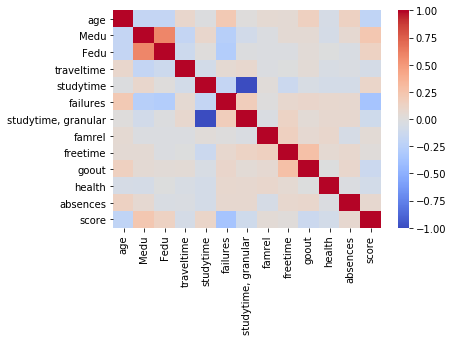

In [82]:
sns.heatmap(correlation, cmap = 'coolwarm')

Из тепловой карты видно, что мы имеем два полностью скоррелированных признака studytime и studytime, granular, поэтому один из них можно удалить. Так как studytime, granular неинформативный признак, удаляем его.

In [83]:
students = students.drop(['studytime, granular'], axis = 1)

Далее мы видим, что наиболее скоррелированные со score признаки это: age, Medu, Fedu, studytime, failures.

Посмотрим, различаются ли распределения оценок в зависимости от номинативных переменных. Сделаем это с помощью box-plot. Создадим функцию для построения боксплотов и будем применять ее к каждой колонке с категориальными значениями: ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup','paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']

In [84]:
def get_boxplot(column):
    fig, ax = plt.subplots(figsize = (14, 4))
    sns.boxplot(x = column, y = 'score', 
                data = students, ax=ax)
    plt.xticks(rotation=45)
    ax.set_title('Boxplot for ' + column)
    plt.show()

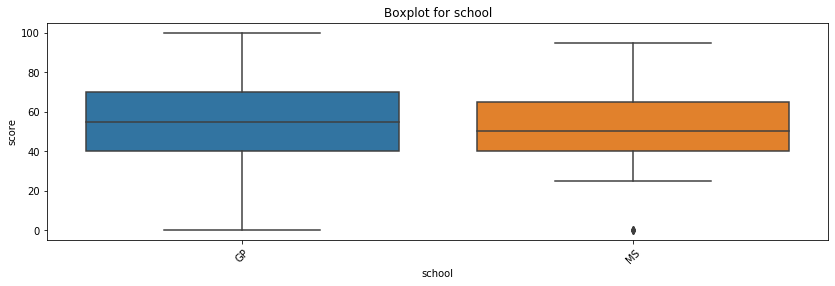

In [85]:
get_boxplot('school')

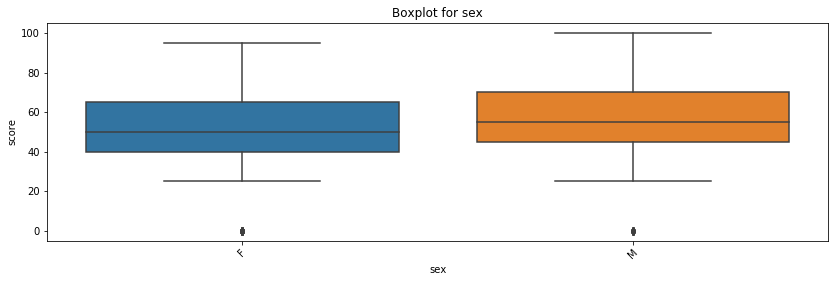

In [86]:
get_boxplot('sex')

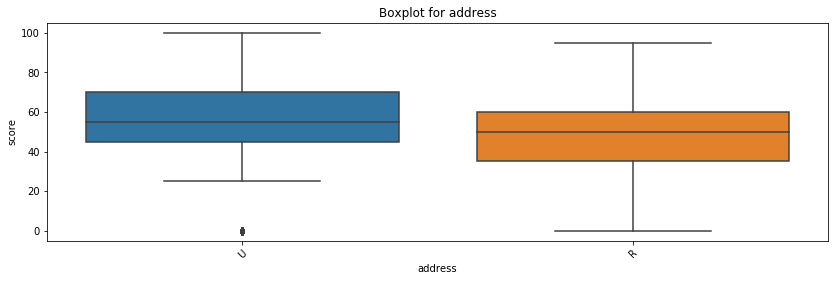

In [87]:
get_boxplot('address')

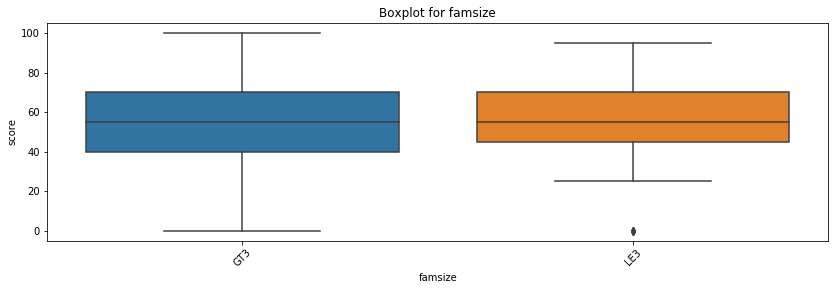

In [88]:
get_boxplot('famsize')

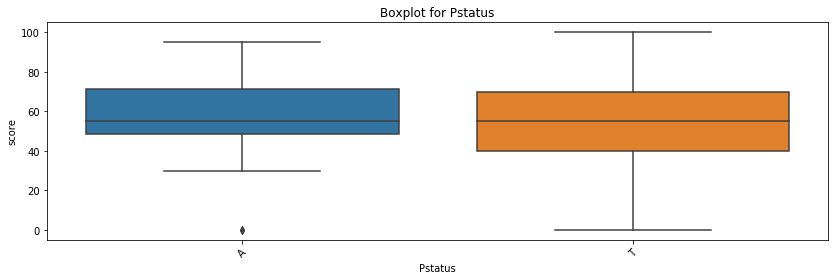

In [89]:
get_boxplot('Pstatus')

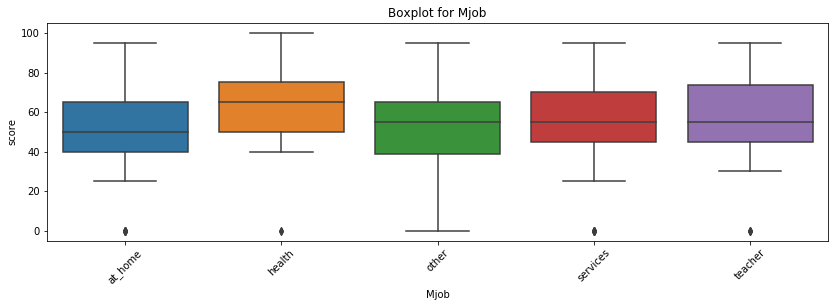

In [90]:
get_boxplot('Mjob')

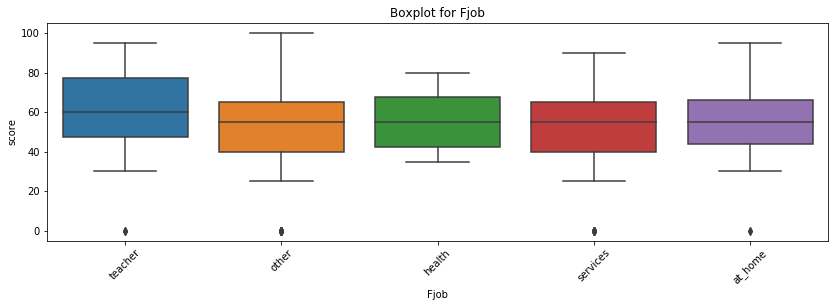

In [91]:
get_boxplot('Fjob')

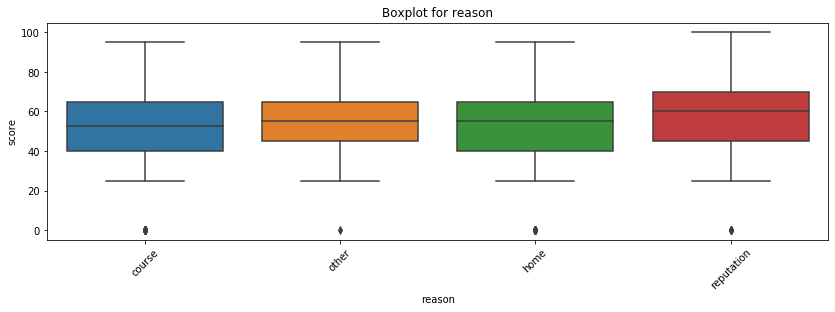

In [92]:
get_boxplot('reason')

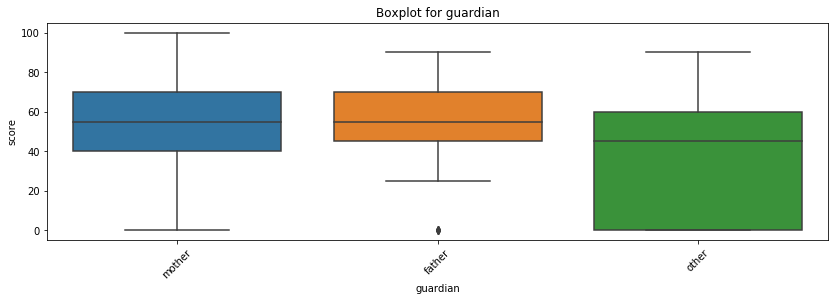

In [93]:
get_boxplot('guardian')

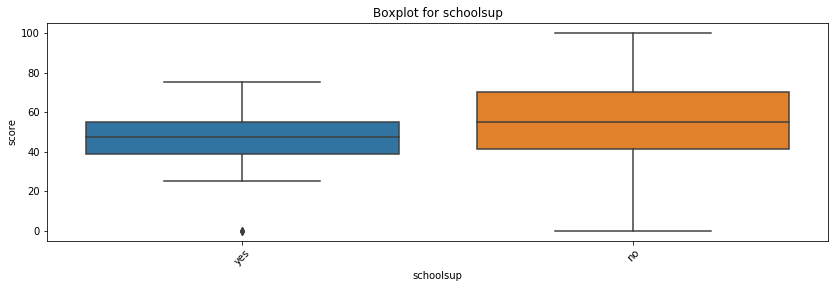

In [94]:
get_boxplot('schoolsup')

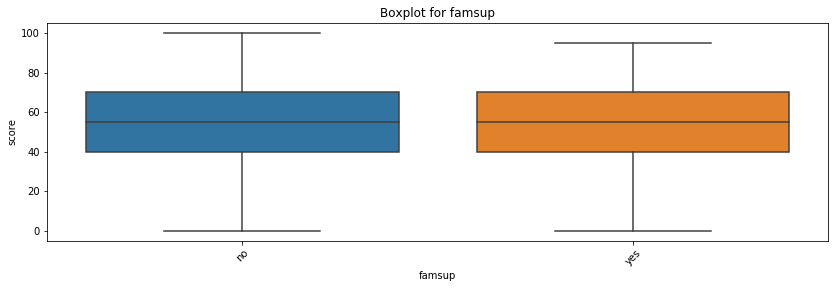

In [95]:
get_boxplot('famsup')

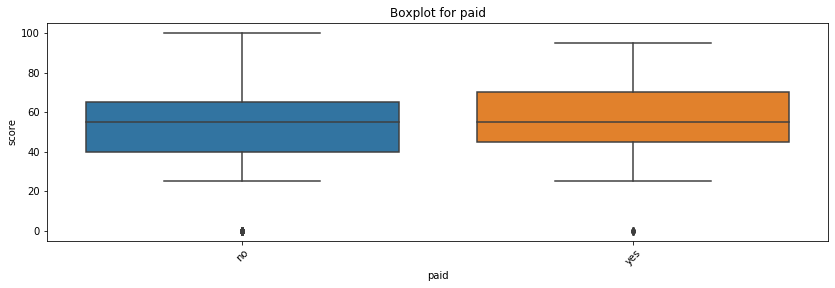

In [96]:
get_boxplot('paid')

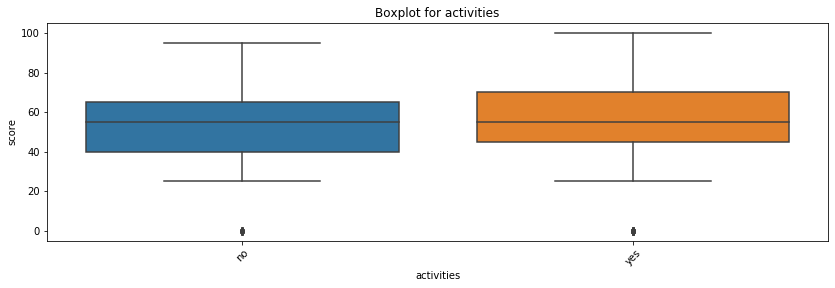

In [97]:
get_boxplot('activities')

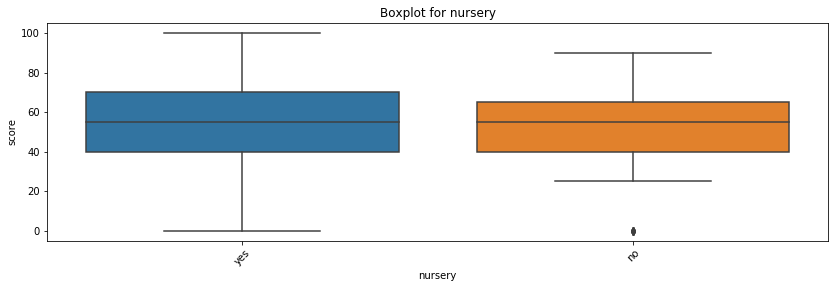

In [98]:
get_boxplot('nursery')

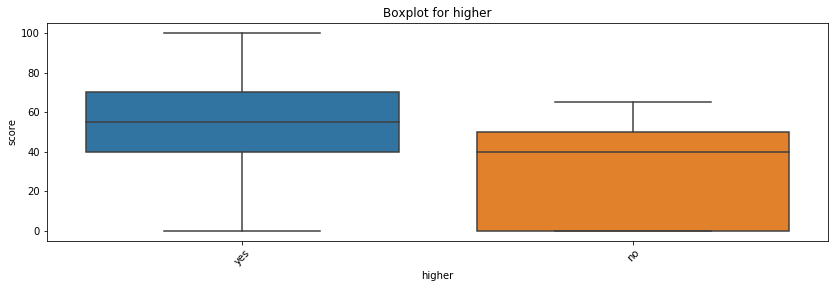

In [99]:
get_boxplot('higher')

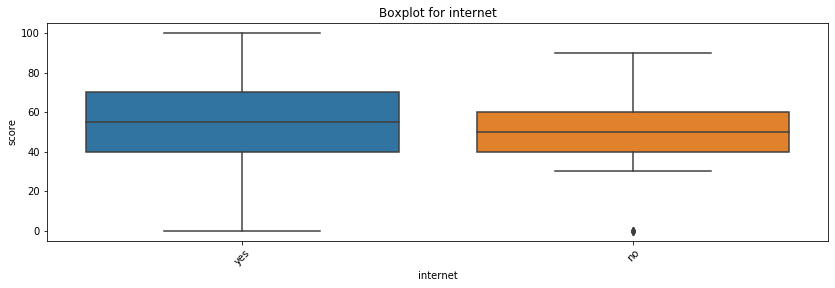

In [100]:
get_boxplot('internet')

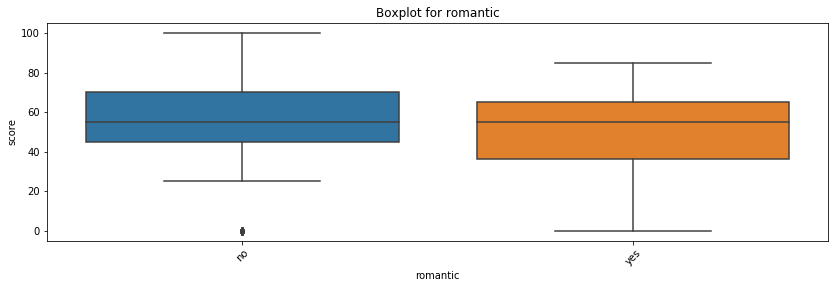

In [101]:
get_boxplot('romantic')

Проверим, есть ли статистическая разница в распределении оценок по номинативным признакам с помощью теста Стьюдента.

In [102]:
def get_stat_dif(column):
    cols = students.loc[:, column].value_counts().index
    combinations_all = list(combinations(cols, 2))
    for comb in combinations_all:
        if ttest_ind(students.loc[students.loc[:, column] == comb[0], 'score'], 
                        students.loc[students.loc[:, column] == comb[1], 'score']).pvalue \
            <= 0.05/len(combinations_all): # Учли поправку Бонферони
            print('Найдены статистически значимые различия для колонки', column)
            break

In [103]:
for col in ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup',\
            'famsup','paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']:
    get_stat_dif(col)

Найдены статистически значимые различия для колонки sex
Найдены статистически значимые различия для колонки Mjob
Найдены статистически значимые различия для колонки guardian
Найдены статистически значимые различия для колонки schoolsup
Найдены статистически значимые различия для колонки paid
Найдены статистически значимые различия для колонки higher
Найдены статистически значимые различия для колонки romantic


Как мы видим различия имеют следующие параметры:  sex, Mjob, guardian, schoolsup, paid, higher и romantic.

Итак, важные переменные, которые, возможно, оказывают влияние на оценку, это: sex, age, Medu, Fedu, Mjob, guardian, studytime, failures, schoolsup, paid, higher и romantic.

In [105]:
students_for_model = students.loc[:, ['sex', 'age', 'Medu', 'Fedu', 'Mjob', 'guardian', 'studytime', 'failures', 'schoolsup',\
                                      'paid', 'higher', 'romantic']]
students_for_model.head()

,sex,age,Medu,Fedu,Mjob,guardian,studytime,failures,schoolsup,paid,higher,romantic
0,F,18,4.0,4.0,at_home,mother,2.0,0.0,yes,no,yes,no
1,F,17,1.0,1.0,at_home,father,2.0,0.0,no,no,yes,no
2,F,15,1.0,1.0,at_home,mother,2.0,3.0,yes,no,yes,no
3,F,15,4.0,2.0,health,mother,3.0,0.0,no,yes,yes,yes
4,F,16,3.0,3.0,other,father,2.0,0.0,no,yes,yes,no


# Выводы

В результате разведывательного анализа влияния различных признаков учеников на результаты их экзамена по математике были сделаы следующие выводы:
- в большинстве колонок присутствует порядка 10% пустых значений
- наличие большого количества выбросов наблюдалось только в колонке absences, все эти значения были обрезаны
- самые важные параметры, которые предлагается использовать в дальнейшем для построения модели: sex, age, Medu, Fedu, Mjob, guardian, studytime, failures, schoolsup, paid, higher и romantic.